<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana6/Dia1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Com Overfitting

-> 2. Estruturando o pipeline de Treino e Validação...
Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.

-> 3. Treinando a CNN com Overfitting proposital...
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8034 - loss: 0.4263 - val_accuracy: 0.9287 - val_loss: 0.2151
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9278 - loss: 0.2163 - val_accuracy: 0.9216 - val_loss: 0.2373
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9433 - loss: 0.1675 - val_accuracy: 0.9294 - val_loss: 0.2143
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9581 - loss: 0.1216 - val_accuracy: 0.9183 - val_loss: 0.2490
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9701 - loss: 0.0883 - val_accuracy: 0.9301 - val_loss: 0.2526
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9789 - loss: 0.0621 - val_accu

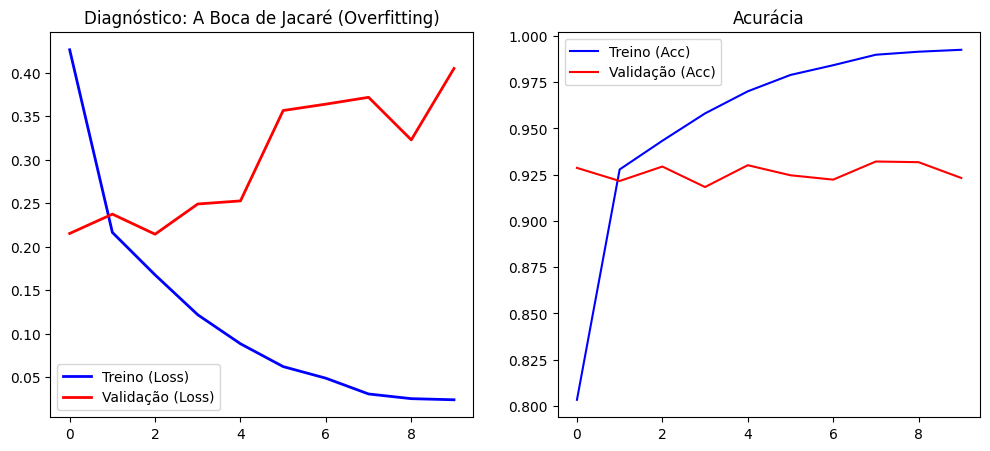

In [ ]:
# ==============================================================================
# 1. DOWNLOAD DIRETO VIA LINUX (CORREÇÃO DO ERRO DE DIRETÓRIO)
# ==============================================================================
# O '!' avisa ao Colab para rodar direto no terminal do servidor
!wget -q -nc https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
!unzip -q -n cell_images.zip

import tensorflow as tf
import matplotlib.pyplot as plt

print("-> 2. Estruturando o pipeline de Treino e Validação...")
# O unzip joga a pasta 'cell_images' na raiz do Colab
pasta_base = 'cell_images'

dados_treino = tf.keras.utils.image_dataset_from_directory(
    pasta_base, validation_split=0.2, subset="training", seed=123,
    image_size=(130, 130), batch_size=32
)

dados_val = tf.keras.utils.image_dataset_from_directory(
    pasta_base, validation_split=0.2, subset="validation", seed=123,
    image_size=(130, 130), batch_size=32
)

dados_treino = dados_treino.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
dados_val = dados_val.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ==============================================================================
# 3. A ARMADILHA (CRIANDO UM MODELO INGENUO PARA FORÇAR O ERRO)
# ==============================================================================
print("\n-> 3. Treinando a CNN com Overfitting proposital...")
modelo_ingenuo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(130, 130, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_ingenuo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
historico = modelo_ingenuo.fit(dados_treino, validation_data=dados_val, epochs=10, verbose=1)

# ==============================================================================
# 4. A AUDITORIA (LENDO O ELETROCARDIOGRAMA)
# ==============================================================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Treino (Loss)', color='blue', linewidth=2)
plt.plot(historico.history['val_loss'], label='Validação (Loss)', color='red', linewidth=2)
plt.title("Diagnóstico: A Boca de Jacaré (Overfitting)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico.history['accuracy'], label='Treino (Acc)', color='blue')
plt.plot(historico.history['val_accuracy'], label='Validação (Acc)', color='red')
plt.title("Acurácia")
plt.legend()
plt.show()

## Sem overfitting

A CURA: DROPOUT, BATCH NORMALIZATION E AUGMENTATION
Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.5628 - loss: 0.8733 - val_accuracy: 0.5865 - val_loss: 0.6624
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5707 - loss: 0.6869 - val_accuracy: 0.6736 - val_loss: 0.6486
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5826 - loss: 0.6757 - val_accuracy: 0.4972 - val_loss: 0.7971
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5969 - loss: 0.6648 - val_accuracy: 0.7258 - val_loss: 0.6030
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6580 - loss: 0.5964 - val_accuracy: 0.8356 - val_loss: 0.6141
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.7025 - loss: 0.5606 - val_accuracy: 0.9160 - val_loss: 0.3770
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7553 - loss: 0.5098 - val_accuracy: 0.9185 - val_loss: 0.3315
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━

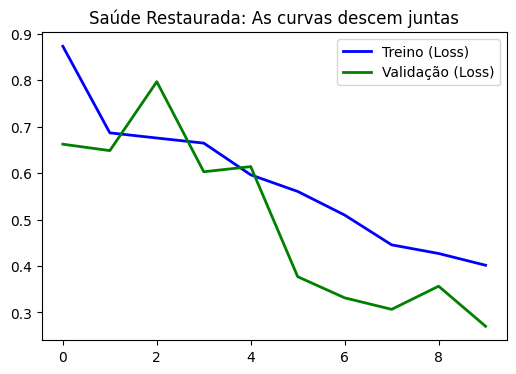

In [ ]:
print("="*75)
print("A CURA: DROPOUT, BATCH NORMALIZATION E AUGMENTATION")
print("="*75)

# 1. Augmentation Físico Avançado (Simulando lentes e iluminações variadas)
def augmentation_avancado(imagem, rotulo):
    imagem = tf.image.random_brightness(imagem, max_delta=0.2)
    imagem = tf.image.random_contrast(imagem, lower=0.8, upper=1.2)
    imagem = tf.image.random_flip_left_right(imagem)
    imagem = tf.image.random_flip_up_down(imagem)
    return tf.clip_by_value(imagem, 0.0, 255.0), rotulo # Mantém os pixels seguros antes do Rescaling

dados_treino_aug = dados_treino.map(augmentation_avancado).prefetch(tf.data.AUTOTUNE)

# 2. A Arquitetura Profissional Blindada
modelo_blindado = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(130, 130, 3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(), # Estabiliza a matemática da camada
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # A Vacina: Desliga 50% dos neurônios no treino!
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_blindado.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Treinamento Implacável
historico_blindado = modelo_blindado.fit(dados_treino_aug, validation_data=dados_val, epochs=10, verbose=1)

# 4. Comprovação Gráfica (O Fim do Jacaré)
plt.figure(figsize=(6, 4))
plt.plot(historico_blindado.history['loss'], label='Treino (Loss)', color='blue', linewidth=2)
plt.plot(historico_blindado.history['val_loss'], label='Validação (Loss)', color='green', linewidth=2)
plt.title("Saúde Restaurada: As curvas descem juntas")
plt.legend()
plt.show()